In [128]:
import pandas as pd

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [129]:
# Load training data
history = pd.read_csv('https://raw.githubusercontent.com/samsung-ai-course/8th-9th-edition/main/Supervised%20learning%20Hackathon%20-%20Edition%209/data/history.csv')
history.head(2)
history.shape

,id,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,37980,32.0,male,Associate,96865.0,10,MORTGAGE,7500.0,EDUCATION,6.04,0.08,10.0,601,No,0
1,9912,24.0,male,Associate,56838.0,6,RENT,9000.0,EDUCATION,11.49,0.16,4.0,647,Yes,0


(38250, 15)

In [130]:
history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38250 entries, 0 to 38249
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              38250 non-null  int64  
 1   person_age                      38250 non-null  float64
 2   person_gender                   38250 non-null  object 
 3   person_education                38250 non-null  object 
 4   person_income                   38250 non-null  float64
 5   person_emp_exp                  38250 non-null  int64  
 6   person_home_ownership           38250 non-null  object 
 7   loan_amnt                       38250 non-null  float64
 8   loan_intent                     38250 non-null  object 
 9   loan_int_rate                   38250 non-null  float64
 10  loan_percent_income             38250 non-null  float64
 11  cb_person_cred_hist_length      38250 non-null  float64
 12  credit_score                    

In [131]:
history['person_gender'].value_counts()

,count
person_gender,
male,21103
female,17147


In [132]:
history['person_gender'] = history['person_gender'].replace({'male': 0, 'female': 1})

/tmp/ipython-input-3418623177.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  history['person_gender'] = history['person_gender'].replace({'male': 0, 'female': 1})


In [133]:
history['person_education'].value_counts()

,count
person_education,
Bachelor,11382
High School,10220
Associate,10194
Master,5913
Doctorate,541


In [134]:
history['person_education'] = history['person_education'].replace({'Bachelor': 0, 'High School': 1, 'Associate': 2, 'Master': 3, 'Doctorate': 4})

/tmp/ipython-input-720022216.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  history['person_education'] = history['person_education'].replace({'Bachelor': 0, 'High School': 1, 'Associate': 2, 'Master': 3, 'Doctorate': 4})


In [135]:
history['loan_intent'].value_counts()

,count
loan_intent,
EDUCATION,7780
MEDICAL,7257
VENTURE,6677
PERSONAL,6407
DEBTCONSOLIDATION,6052
HOMEIMPROVEMENT,4077


In [136]:
history['loan_intent'] = history['loan_intent'].replace({'EDUCATION': 0, 'MEDICAL': 1, 'VENTURE': 2, 'PERSONAL': 3, 'DEBTCONSOLIDATION': 4, 'HOMEIMPROVEMENT': 5})

/tmp/ipython-input-3884243055.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  history['loan_intent'] = history['loan_intent'].replace({'EDUCATION': 0, 'MEDICAL': 1, 'VENTURE': 2, 'PERSONAL': 3, 'DEBTCONSOLIDATION': 4, 'HOMEIMPROVEMENT': 5})


In [137]:
history['previous_loan_defaults_on_file'].value_counts()

,count
previous_loan_defaults_on_file,
Yes,19425
No,18825


In [138]:
history['previous_loan_defaults_on_file'] = history['previous_loan_defaults_on_file'].replace({'Yes': 0, 'No': 1})

/tmp/ipython-input-1443841575.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  history['previous_loan_defaults_on_file'] = history['previous_loan_defaults_on_file'].replace({'Yes': 0, 'No': 1})


In [139]:
history['loan_status'].value_counts()

,count
loan_status,
0,29761
1,8489


In [140]:
history['person_home_ownership'].value_counts()

,count
person_home_ownership,
RENT,19929
MORTGAGE,15742
OWN,2477
OTHER,102


In [141]:
history['person_home_ownership'] = history['person_home_ownership'].replace({'RENT': 0, 'MORTGAGE': 1, 'OWN': 2, 'OTHER': 3})

/tmp/ipython-input-1785946384.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  history['person_home_ownership'] = history['person_home_ownership'].replace({'RENT': 0, 'MORTGAGE': 1, 'OWN': 2, 'OTHER': 3})


In [142]:
y = history['loan_status']
X = history.drop(columns=['loan_status','id'])

In [143]:
X.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,32.0,0,2,96865.0,10,1,7500.0,0,6.04,0.08,10.0,601,1
1,24.0,0,2,56838.0,6,0,9000.0,0,11.49,0.16,4.0,647,0
2,22.0,1,3,37298.0,0,0,5000.0,1,14.88,0.13,4.0,711,1
3,23.0,1,0,39944.0,1,2,5000.0,2,13.99,0.13,3.0,597,0
4,42.0,0,1,67974.0,20,1,10000.0,5,15.41,0.15,11.0,586,1


In [144]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

In [145]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [146]:
from sklearn.preprocessing import StandardScaler

In [147]:
# TODO: Scale features (important for some algorithms)
scaler = StandardScaler()
# YOUR CODE HERE - fit and transform encoded training data
X_train_scaled = scaler.fit_transform(X_train)
# YOUR CODE HERE - transform encoded test data
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully!")
print(f"Scaled features mean: {X_train_scaled.mean():.6f}")
print(f"Scaled features std: {X_train_scaled.std():.6f}")


Features scaled successfully!
Scaled features mean: 0.000000
Scaled features std: 1.000000


In [148]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [149]:
# TODO: Train baseline Logistic Regression
lr_baseline = LogisticRegression(random_state=42)
# YOUR CODE HERE - fit on scaled data
lr_baseline.fit(X_train_scaled, y_train)

# TODO: Make predictions and evaluate
# YOUR CODE HERE
y_pred_lr = lr_baseline.predict(X_test_scaled)
f1_lr = f1_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test,y_pred_lr)

print(f"Logistic Regression Baseline F1 Score: {f1_lr:.4f}")
print(f"Logistic Regression Baseline Precision Score: {precision_lr:.4f}")
print(f"Logistic Regression Baseline Accuracy Score: {accuracy_lr:.4f}")
print(f"Logistic Regression Baseline Recall Score: {recall_lr:.4f}")

LogisticRegression(random_state=42)

Logistic Regression Baseline F1 Score: 0.7529
Logistic Regression Baseline Precision Score: 0.7722
Logistic Regression Baseline Accuracy Score: 0.8939
Logistic Regression Baseline Recall Score: 0.7346


In [150]:
# TODO: Train baseline KNN (start with k=5)
knn_baseline = KNeighborsClassifier(n_neighbors= 5)
# YOUR CODE HERE - fit on scaled data
knn_baseline = knn_baseline.fit(X_train_scaled,y_train)

# TODO: Make predictions and evaluate
y_pred_knn = knn_baseline.predict(X_test_scaled)
f1_knn = f1_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test,y_pred_knn)

print(f"KNN Baseline F1 Score: {f1_knn:.4f}")
print(f"KNN Baseline Precision Score: {precision_knn:.4f}")
print(f"KNN Regression Baseline Accuracy Score: {accuracy_knn:.4f}")
print(f"KNN Regression Baseline Recall Score: {recall_knn:.4f}")

KNN Baseline F1 Score: 0.7450
KNN Baseline Precision Score: 0.7929
KNN Regression Baseline Accuracy Score: 0.8941
KNN Regression Baseline Recall Score: 0.7025


In [151]:
# TODO: Train baseline SVM (use default RBF kernel)
svm_baseline = SVC(random_state=42)
# YOUR CODE HERE - fit on scaled data
svm_baseline = svm_baseline.fit(X_train_scaled, y_train)
# TODO: Make predictions and evaluate
y_pred_svm = svm_baseline.predict(X_test_scaled)
precision_svm = precision_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test,y_pred_svm)

print(f"SVM Baseline F1 Score: {f1_svm:.4f}")
print(f"SVM Baseline Precision: {precision_svm:.4f}")
print(f"SVM Baseline Accuracy Score: {accuracy_svm:.4f}")
print(f"SVM Baseline Recall Score: {recall_svm:.4f}")

SVM Baseline F1 Score: 0.7799
SVM Baseline Precision: 0.8223
SVM Baseline Accuracy Score: 0.9078
SVM Baseline Recall Score: 0.7417


In [152]:
# TODO: Train baseline Decision Tree
dt_baseline = DecisionTreeClassifier(random_state=42)
# YOUR CODE HERE - fit on original (unscaled) data
dt_baseline = dt_baseline.fit(X_train, y_train)
# TODO: Make predictions and evaluate
y_pred_dt = dt_baseline.predict(X_test)
precision_dt = precision_score(y_test,y_pred_dt)
f1_dt = f1_score(y_test,y_pred_dt)
accuracy_dt = accuracy_score(y_test,y_pred_dt)
recall_dt = recall_score(y_test,y_pred_dt)

print(f"Decision Tree Baseline F1: {f1_dt:.4f}")
print(f"Decision Tree Baseline Precision: {precision_dt:.4f}")
print(f"Decision Tree Baseline Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Baseline Recall: {recall_dt:.4f}")

Decision Tree Baseline F1: 0.7673
Decision Tree Baseline Precision: 0.7575
Decision Tree Baseline Accuracy: 0.8962
Decision Tree Baseline Recall: 0.7773


In [153]:
# TODO: Train baseline Random Forest
rf_baseline = RandomForestClassifier(random_state=42)
# YOUR CODE HERE - fit on original (unscaled) data
rf_baseline = rf_baseline.fit(X_train, y_train)
# TODO: Make predictions and evaluate
y_pred_rf = rf_baseline.predict(X_test)
precision_rf = precision_score(y_test, y_pred_rf)
accuracy_rf = accuracy_score(y_test,y_pred_rf)
f1_rf = f1_score(y_test,y_pred_rf)
recall_rf = recall_score(y_test,y_pred_rf)

print(f"Random Forest Baseline F1: {f1_rf:.4f}")
print(f"Random Forest Baseline Precision: {precision_rf:.4f}")
print(f"Random Forest Baseline Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Baseline Recall: {recall_rf:.4f}")

Random Forest Baseline F1: 0.8254
Random Forest Baseline Precision: 0.8884
Random Forest Baseline Accuracy: 0.9282
Random Forest Baseline Recall: 0.7708


In [154]:
import numpy as np
import matplotlib.pyplot as plt

Baseline Model Comparison:
              Model  Precision
      Random Forest   0.888433
                SVM   0.822251
                KNN   0.792895
Logistic Regression   0.772160
      Decision Tree   0.757523


<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Baseline Model Precision Comparison')

Text(0, 0.5, 'Precision')

Text(0.5, 0, 'Model')

...

Text(0.0, 0.8984325804243669, '0.888')

Text(1.0, 0.8322514812376564, '0.822')

Text(2.0, 0.8028954423592494, '0.793')

Text(3.0, 0.7821598002496879, '0.772')

Text(4.0, 0.7675231481481481, '0.758')

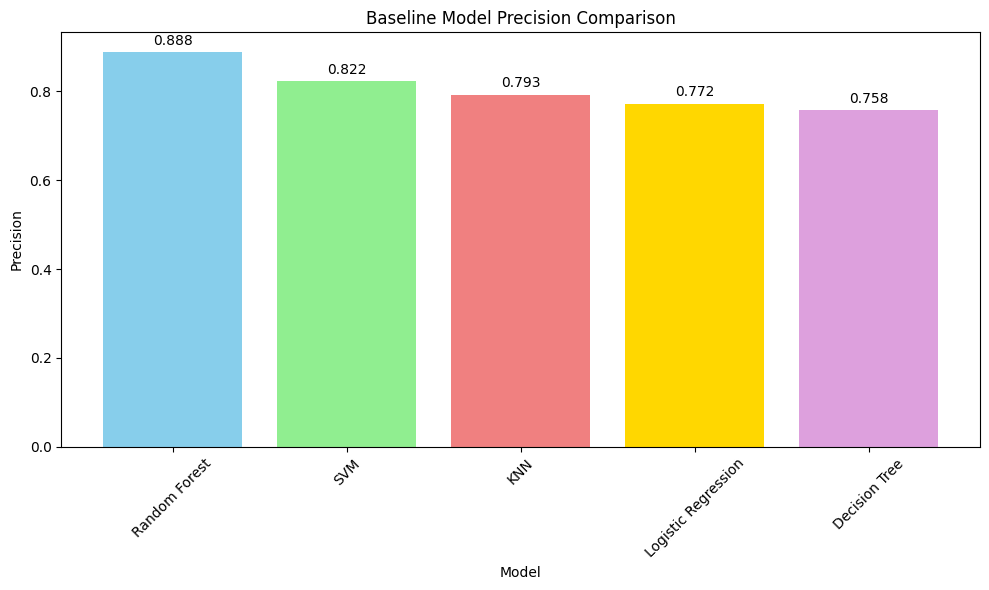

In [155]:
# TODO: Create comparison of baseline models
baseline_results = {
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest'],
    'Precision': [precision_lr, precision_knn, precision_svm, precision_dt, precision_rf]
}

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.sort_values('Precision', ascending=False)

print("Baseline Model Comparison:")
print(baseline_df.to_string(index=False))

# TODO: Visualize the results
plt.figure(figsize=(10, 6))
bars = plt.bar(baseline_df['Model'], baseline_df['Precision'], color=['skyblue', 'lightgreen', 'lightcoral', 'gold', 'plum'])
plt.title('Baseline Model Precision Comparison')
plt.ylabel('Precision')
plt.xlabel('Model')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, acc in zip(bars, baseline_df['Precision']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Baseline Model Comparison:
              Model       F1
      Random Forest 0.825437
                SVM 0.779894
      Decision Tree 0.767292
Logistic Regression 0.752891
                KNN 0.744962


<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Baseline Model F1 Comparison')

Text(0, 0.5, 'F1')

Text(0.5, 0, 'Model')

...

Text(0.0, 0.8354372019077901, '0.825')

Text(1.0, 0.7898938495160787, '0.780')

Text(2.0, 0.7772919109026963, '0.767')

Text(3.0, 0.7628910529519173, '0.753')

Text(4.0, 0.7549622166246851, '0.745')

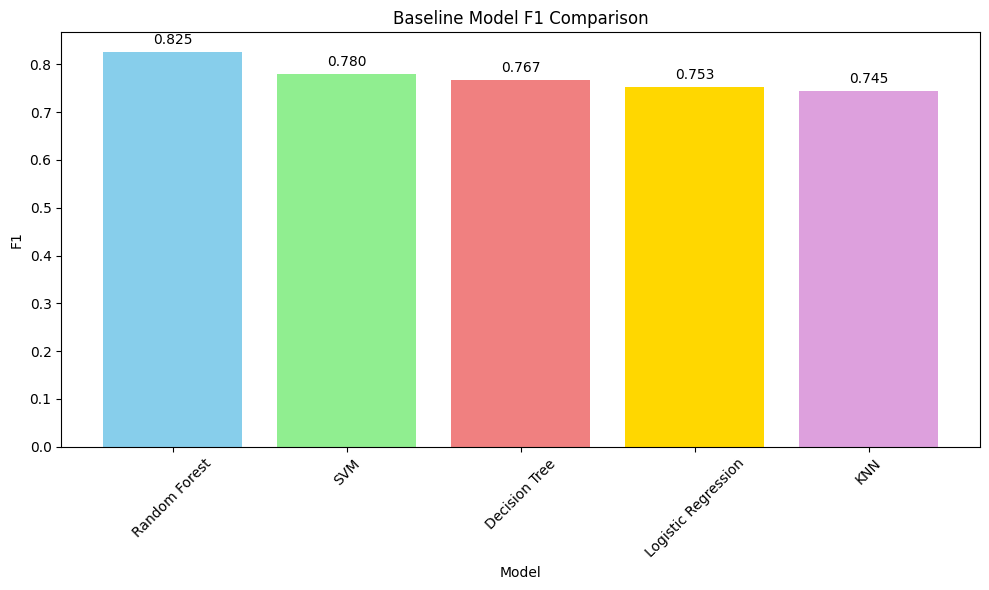

In [156]:
# TODO: Create comparison of baseline models
baseline_results = {
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest'],
    'F1': [f1_lr, f1_knn, f1_svm, f1_dt, f1_rf]
}

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.sort_values('F1', ascending=False)

print("Baseline Model Comparison:")
print(baseline_df.to_string(index=False))

# TODO: Visualize the results
plt.figure(figsize=(10, 6))
bars = plt.bar(baseline_df['Model'], baseline_df['F1'], color=['skyblue', 'lightgreen', 'lightcoral', 'gold', 'plum'])
plt.title('Baseline Model F1 Comparison')
plt.ylabel('F1')
plt.xlabel('Model')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, acc in zip(bars, baseline_df['F1']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Baseline Model Comparison:
              Model  Accuracy
      Random Forest  0.928235
                SVM  0.907843
      Decision Tree  0.896209
                KNN  0.894118
Logistic Regression  0.893856


<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Baseline Model Accuracy Comparison')

Text(0, 0.5, 'Accuracy')

Text(0.5, 0, 'Model')

...

Text(0.0, 0.9382352941176471, '0.928')

Text(1.0, 0.917843137254902, '0.908')

Text(2.0, 0.9062091503267974, '0.896')

Text(3.0, 0.9041176470588236, '0.894')

Text(4.0, 0.9038562091503268, '0.894')

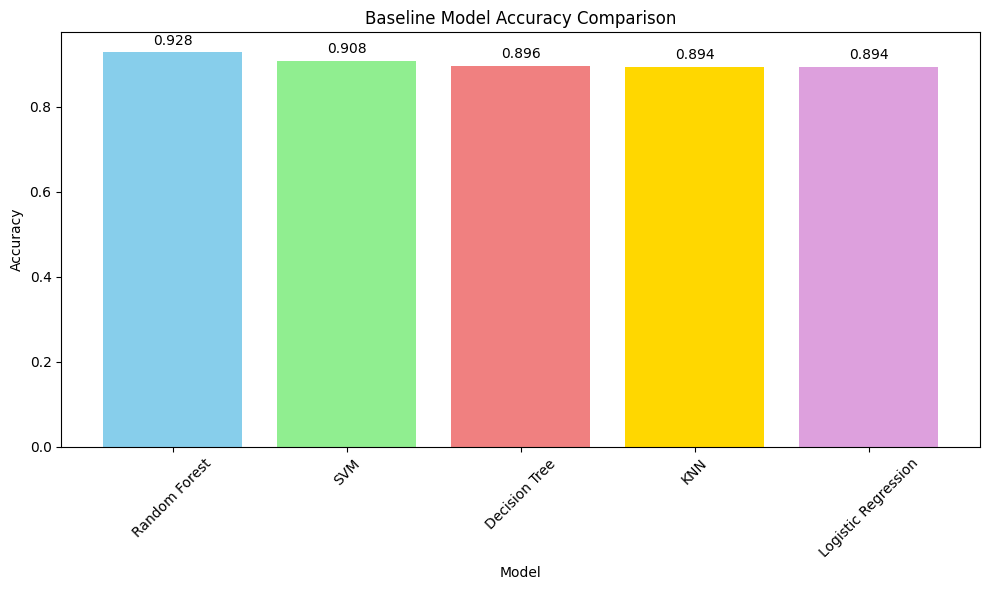

In [157]:
# TODO: Create comparison of baseline models
baseline_results = {
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_knn, accuracy_svm, accuracy_dt, accuracy_rf]
}

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.sort_values('Accuracy', ascending=False)

print("Baseline Model Comparison:")
print(baseline_df.to_string(index=False))

# TODO: Visualize the results
plt.figure(figsize=(10, 6))
bars = plt.bar(baseline_df['Model'], baseline_df['Accuracy'], color=['skyblue', 'lightgreen', 'lightcoral', 'gold', 'plum'])
plt.title('Baseline Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, acc in zip(bars, baseline_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Baseline Model Comparison:
              Model   Recall
      Decision Tree 0.777316
      Random Forest 0.770784
                SVM 0.741686
Logistic Regression 0.734561
                KNN 0.702494


<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Baseline Model Recall Comparison')

Text(0, 0.5, 'Recall')

Text(0.5, 0, 'Model')

...

Text(0.0, 0.7873159144893112, '0.777')

Text(1.0, 0.7807838479809976, '0.771')

Text(2.0, 0.7516864608076009, '0.742')

Text(3.0, 0.7445605700712589, '0.735')

Text(4.0, 0.7124940617577197, '0.702')

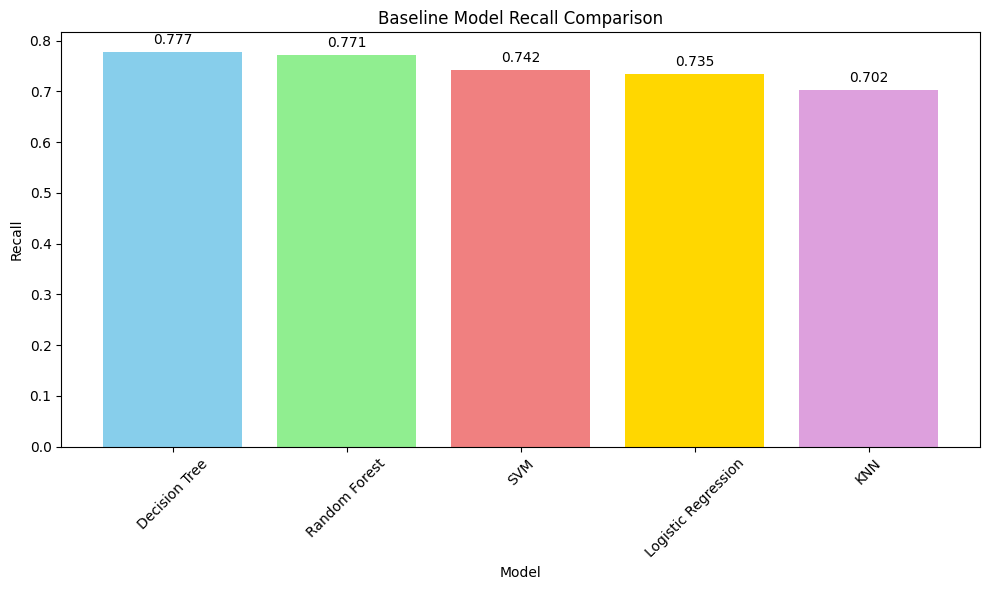

In [158]:
# TODO: Create comparison of baseline models
baseline_results = {
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest'],
    'Recall': [recall_lr, recall_knn, recall_svm, recall_dt, recall_rf]
}

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.sort_values('Recall', ascending=False)

print("Baseline Model Comparison:")
print(baseline_df.to_string(index=False))

# TODO: Visualize the results
plt.figure(figsize=(10, 6))
bars = plt.bar(baseline_df['Model'], baseline_df['Recall'], color=['skyblue', 'lightgreen', 'lightcoral', 'gold', 'plum'])
plt.title('Baseline Model Recall Comparison')
plt.ylabel('Recall')
plt.xlabel('Model')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, acc in zip(bars, baseline_df['Recall']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [159]:
# TODO: Define parameter grids for each model

# Logistic Regression parameters
lr_param_grid = {
    'C': [0.1, 1, 10, 100], # YOUR CODE HERE - try [0.1, 1, 10, 100]
    'penalty': ['l1', 'l2'], # YOUR CODE HERE - try ['l1', 'l2']
    'solver':  ['liblinear', 'saga'] # YOUR CODE HERE - try ['liblinear', 'saga']
}

# KNN parameters
knn_param_grid = {
    'n_neighbors': [3,5,7,9,11], # YOUR CODE HERE - try [3, 5, 7, 9, 11]
    'weights': ['uniform', 'distance'], # YOUR CODE HERE - try ['uniform', 'distance']
    'metric': ['euclidean', 'manhattan'] # YOUR CODE HERE - try ['euclidean', 'manhattan']
}

# SVM parameters
svm_param_grid = {
    'C': [0.1, 1, 10], # YOUR CODE HERE - try [0.1, 1, 10]
    'kernel': ['linear', 'rbf'], # YOUR CODE HERE - try ['linear', 'rbf']
    'gamma': ['scale', 'auto']# YOUR CODE HERE - try ['scale', 'auto']
}

# Decision Tree parameters
dt_param_grid = {
    'max_depth': [3,5,7,10, None], # YOUR CODE HERE - try [3, 5, 7, 10, None]
    'min_samples_split': [2,5,10], # YOUR CODE HERE - try [2, 5, 10]
    'min_samples_leaf': [1,2,4]# YOUR CODE HERE - try [1, 2, 4]
}

# Random Forest parameters
rf_param_grid = {
    'n_estimators': [50,100,200], # YOUR CODE HERE - try [50, 100, 200]
    'max_depth': [3,5,7, None],# YOUR CODE HERE - try [3, 5, 7, None]
    'min_samples_split': [2,5,10]# YOUR CODE HERE - try [2, 5, 10]
}

# Print parameter grid sizes
param_grids = {
    'Logistic Regression': lr_param_grid,
    'KNN': knn_param_grid,
    'SVM': svm_param_grid,
    'Decision Tree': dt_param_grid,
    'Random Forest': rf_param_grid
}

for model_name, param_grid in param_grids.items():
    total_combinations = 1
    for values in param_grid.values():
        total_combinations *= len(values)
    print(f"{model_name}: {total_combinations} parameter combinations")

Logistic Regression: 16 parameter combinations
KNN: 20 parameter combinations
SVM: 12 parameter combinations
Decision Tree: 45 parameter combinations
Random Forest: 36 parameter combinations


In [160]:
# TODO: Setup models and data for grid search
# Note: Some models work better with scaled data, others with original data
models = {
    'Logistic Regression': (LogisticRegression(random_state=42, max_iter=1000), lr_param_grid, X_train_scaled[:500]),
    'KNN': (KNeighborsClassifier(), knn_param_grid, X_train_scaled[:500]),
    'SVM': (SVC(random_state=42), svm_param_grid, X_train_scaled[:500]),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), dt_param_grid, X_train[:500]),
    'Random Forest': (RandomForestClassifier(random_state=42), rf_param_grid, X_train[:500])
}

# Store results
grid_search_results = {}

# TODO: Set your chosen metric from the previous section
scoring_metric = 'precision3'
print(f"Starting Grid Search for all models using '{scoring_metric}' metric...")
print("This might take a few minutes...\n")

Starting Grid Search for all models using 'precision3' metric...
This might take a few minutes...



In [161]:
# EXAMPLE: Grid Search for Logistic Regression
print("🔍 EXAMPLE: Grid Search for Logistic Regression")
lr_model, lr_grid, lr_data = models['Logistic Regression']

# Create GridSearchCV object
lr_grid_search = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_grid,
    cv=5,
    scoring=scoring_metric,
    n_jobs=-1,  # Use all available cores
    verbose=1   # Show progress
)

# Fit the grid search
print("Fitting Logistic Regression...")
lr_grid_search.fit(lr_data, y_train[:500])

# Store results
grid_search_results['Logistic Regression'] = lr_grid_search
print(f"✅ Best params: {lr_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {lr_grid_search.best_score_:.4f}\n")

🔍 EXAMPLE: Grid Search for Logistic Regression
Fitting Logistic Regression...


InvalidParameterError: The 'scoring' parameter of GridSearchCV must be a str among {'roc_auc_ovo_weighted', 'f1_samples', 'neg_brier_score', 'matthews_corrcoef', 'recall_macro', 'accuracy', 'homogeneity_score', 'jaccard_macro', 'average_precision', 'neg_max_error', 'fowlkes_mallows_score', 'adjusted_mutual_info_score', 'neg_mean_absolute_error', 'completeness_score', 'neg_mean_gamma_deviance', 'neg_negative_likelihood_ratio', 'normalized_mutual_info_score', 'recall_samples', 'neg_median_absolute_error', 'f1_macro', 'd2_absolute_error_score', 'r2', 'f1', 'recall_weighted', 'adjusted_rand_score', 'jaccard_samples', 'positive_likelihood_ratio', 'top_k_accuracy', 'balanced_accuracy', 'jaccard_micro', 'neg_mean_squared_log_error', 'neg_root_mean_squared_log_error', 'explained_variance', 'v_measure_score', 'f1_micro', 'precision_macro', 'f1_weighted', 'neg_mean_poisson_deviance', 'jaccard', 'neg_root_mean_squared_error', 'roc_auc_ovr_weighted', 'mutual_info_score', 'precision_weighted', 'ran

In [162]:
# EXAMPLE: Grid Search for KNN (another example for you)
print("🔍 EXAMPLE: Grid Search for KNN")
knn_model, knn_grid, knn_data = models['KNN']

# TODO: Create GridSearchCV object following the Logistic Regression example
knn_grid_search = GridSearchCV(
    estimator= knn_model,
    param_grid= knn_grid,
    cv=5,
    scoring=scoring_metric,
    n_jobs=-1,
    verbose=1
)

# TODO: Fit the grid search
print("Fitting KNN...")
# YOUR CODE HERE - fit knn_grid_search
knn_grid_search.fit(knn_data, y_train[:500])

# Store results
grid_search_results['KNN'] = knn_grid_search
print(f"✅ Best params: {knn_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {knn_grid_search.best_score_:.4f}\n")

🔍 EXAMPLE: Grid Search for KNN
Fitting KNN...


InvalidParameterError: The 'scoring' parameter of GridSearchCV must be a str among {'roc_auc_ovo_weighted', 'f1_samples', 'neg_brier_score', 'matthews_corrcoef', 'recall_macro', 'accuracy', 'homogeneity_score', 'jaccard_macro', 'average_precision', 'neg_max_error', 'fowlkes_mallows_score', 'adjusted_mutual_info_score', 'neg_mean_absolute_error', 'completeness_score', 'neg_mean_gamma_deviance', 'neg_negative_likelihood_ratio', 'normalized_mutual_info_score', 'recall_samples', 'neg_median_absolute_error', 'f1_macro', 'd2_absolute_error_score', 'r2', 'f1', 'recall_weighted', 'adjusted_rand_score', 'jaccard_samples', 'positive_likelihood_ratio', 'top_k_accuracy', 'balanced_accuracy', 'jaccard_micro', 'neg_mean_squared_log_error', 'neg_root_mean_squared_log_error', 'explained_variance', 'v_measure_score', 'f1_micro', 'precision_macro', 'f1_weighted', 'neg_mean_poisson_deviance', 'jaccard', 'neg_root_mean_squared_error', 'roc_auc_ovr_weighted', 'mutual_info_score', 'precision_weighted', 'ran

In [ ]:
# TODO: Grid Search for SVM (now it's your turn!)
print("🚀 YOUR TURN: Grid Search for SVM")
print("Follow the examples above to implement SVM grid search")

# TODO: Get the SVM model, parameters, and data
svm_model, svm_grid, svm_data = models['SVM']

# TODO: Create and fit GridSearchCV for SVM
svm_grid_search = GridSearchCV(
    estimator= svm_model,
    param_grid= svm_grid,
    cv=5,
    scoring=scoring_metric,
    n_jobs=-1,
    verbose=1
)
# YOUR CODE HERE - fit the grid search
print("Fitting SVM...")
svm_grid_search.fit(svm_data, y_train[:500])

# TODO: Store results and print
grid_search_results['SVM'] = svm_grid_search
print(f"✅ Best params: {svm_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {svm_grid_search.best_score_:.4f}\n")

In [ ]:
# TODO: Grid Search for Decision Tree (your implementation)
print("🚀 YOUR TURN: Grid Search for Decision Tree")

# TODO: Complete this following the pattern above
# Remember: Decision Tree uses X_train_encoded (not scaled data)
dt_model, dt_grid, dt_data = models['Decision Tree']

# YOUR CODE HERE - implement grid search for Decision Tree
dt_grid_search = GridSearchCV(
    estimator = dt_model,
    param_grid = dt_grid,
    cv = 5,
    scoring = scoring_metric,
    n_jobs = -1,
    verbose = 1
)
print("Fitting Decision Tree...")
dt_grid_search.fit(dt_data, y_train[:500])

grid_search_results['Decision Tree'] = dt_grid_search
print(f"✅ Best params: {dt_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {dt_grid_search.best_score_:.4f}\n")

In [ ]:
# TODO: Grid Search for Random Forest (your final implementation)
print("🚀 YOUR TURN: Grid Search for Random Forest")
print("This is your last one - you've got this! 💪")

# TODO: Complete the Random Forest grid search
# Remember: Random Forest also uses X_train_encoded (not scaled data)
rf_model, rf_grid, rf_data = models['Random Forest']

# YOUR CODE HERE - implement grid search for Random Forest
rf_grid_search = GridSearchCV(
    estimator = rf_model,
    param_grid = rf_grid,
    cv = 5,
    scoring = scoring_metric,
    n_jobs = -1,
    verbose = 1
)
# YOUR CODE HERE - fit the grid search
print("Fitting Random Forest...")
rf_grid_search.fit(rf_data, y_train[:500])

grid_search_results['Random Forest'] = rf_grid_search
print(f"✅ Best params: {rf_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {rf_grid_search.best_score_:.4f}\n")

print("🎉 Grid Search completed for all models!")
print("Great job implementing all the grid searches! 🎊")

'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'

In [ ]:
svc_final_model = SVC(C = 0.1, gamma = 'scale', kernel = 'linear')
svc_final_model.fit(X_train_scaled, y_train)
svc_final_pred = svc_final_model.predict(X_test_scaled)
final_f1 = f1_score(y_test,svc_final_pred)
print(final_f1)

'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200

In [178]:
rf_final_model = RandomForestClassifier(max_depth = 3, min_samples_split = 2, n_estimators = 200)
rf_final_model.fit(X_train, y_train)
rf_final_pred = rf_final_model.predict(X_test)
final_precision_again = precision_score(y_test,rf_final_pred)
print(final_precision_again)

RandomForestClassifier(max_depth=3, n_estimators=200)

0.9732262382864793


In [179]:
# Load test data
test = pd.read_csv('https://raw.githubusercontent.com/samsung-ai-course/8th-9th-edition/main/Supervised%20learning%20Hackathon%20-%20Edition%209/data/test.csv')
test.head(2)
test.shape

,id,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,43299,22.0,female,Bachelor,56179.0,0,RENT,5000.0,EDUCATION,11.01,0.09,3.0,571,No
1,15156,23.0,male,Bachelor,151219.0,2,MORTGAGE,35000.0,EDUCATION,8.90,0.23,4.0,561,Yes


(6750, 14)

In [180]:
test['person_gender'] = test['person_gender'].replace({'male': 0, 'female': 1})
test['person_education'] = test['person_education'].replace({'Bachelor': 0, 'High School': 1, 'Associate': 2, 'Master': 3, 'Doctorate': 4})
test['loan_intent'] = test['loan_intent'].replace({'EDUCATION': 0, 'MEDICAL': 1, 'VENTURE': 2, 'PERSONAL': 3, 'DEBTCONSOLIDATION': 4, 'HOMEIMPROVEMENT': 5})
test['person_home_ownership'] = test['person_home_ownership'].replace({'RENT': 0, 'MORTGAGE': 1, 'OWN': 2, 'OTHER': 3})
test['previous_loan_defaults_on_file'] = test['previous_loan_defaults_on_file'].replace({'Yes': 0, 'No': 1})

/tmp/ipython-input-1390904776.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test['person_gender'] = test['person_gender'].replace({'male': 0, 'female': 1})
/tmp/ipython-input-1390904776.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test['person_education'] = test['person_education'].replace({'Bachelor': 0, 'High School': 1, 'Associate': 2, 'Master': 3, 'Doctorate': 4})
/tmp/ipython-input-1390904776.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain th

In [181]:
final_test = test.drop(columns=['id'])

In [184]:
final_test.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22.0,1,0,56179.0,0,0,5000.0,0,11.01,0.09,3.0,571,1
1,23.0,0,0,151219.0,2,1,35000.0,0,8.90,0.23,4.0,561,0
2,23.0,1,2,115855.0,0,1,10000.0,0,7.49,0.09,3.0,614,1
3,39.0,1,1,80392.0,16,0,13751.0,2,9.87,0.17,16.0,687,0
4,29.0,0,1,145057.0,3,2,7500.0,0,7.74,0.05,8.0,682,0


In [185]:
rf_pred_final = rf_final_model.predict(final_test)

In [186]:
id = test['id'].tolist()

In [187]:
df = pd.DataFrame({'id': id, 'pred': rf_pred_final.tolist()})

In [188]:
df.head()

,id,pred
0,43299,0
1,15156,0
2,13780,0
3,33636,0
4,27044,0


In [189]:
df.to_csv('submission_group_C.csv',sep=',',index=False)

In [172]:
# Load sample submission
sample_submission = pd.read_csv('https://raw.githubusercontent.com/samsung-ai-course/8th-9th-edition/main/Supervised%20learning%20Hackathon%20-%20Edition%209/data/sample_submission.csv')
sample_submission.head(2)
sample_submission.shape

,id,pred
0,43299,0
1,15156,1


(6750, 2)